# Introduction to Scikit-Learn & K-Nearest Neighbors (KNN)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

## 0) Load the Dataset & Visualize

Load the Iris dataset.

View summary statistics and plot graphs.


In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
type(iris)

sklearn.utils._bunch.Bunch

In [4]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [6]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
# store features and target separately
x = iris.data
y = iris.target     # 0 = setosa, 1 = virginica, 2 = versicolor
print(x.shape)
print(y.shape)

(150, 4)
(150,)


In [9]:
# convert into pandas data frame
df = pd.DataFrame(data=x, columns=iris.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [11]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


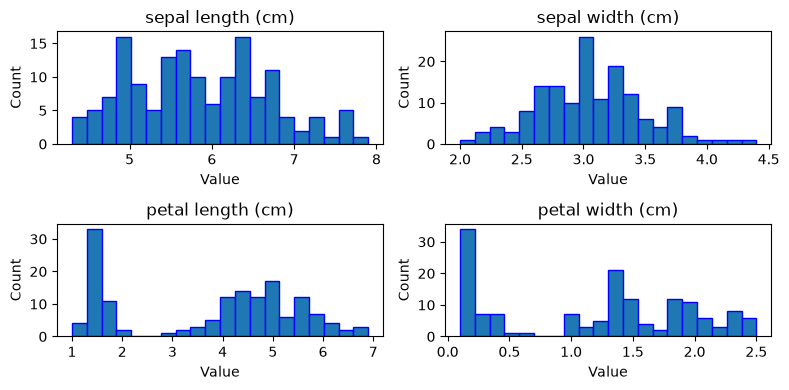

In [12]:
num_features = df.columns
rows = 2
cols = 2

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(8, 4))
axes = axes.flatten()

# Plot each feature
# enumerate -> (i, arr[i])
for i, feature in enumerate(df.columns[: rows * cols]):
    axes[i].hist(df[feature].dropna(), bins=20, edgecolor='blue')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
  
# auto space adjustment to prevent overlap  
plt.tight_layout()

## 1) Preprocess the Dataset & Visualize again

Scaling features ensures each characteristic/feature is equally considered during learning.

Without scaling, larger features may dominate, leading to biased results.

Standard scaling - 0 mean and 1 standard deviation

In [13]:
scaler = preprocessing.StandardScaler()
columns = df.columns[:-1]
df[columns] = scaler.fit_transform(df[columns])

In [14]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02,150.000000
mean,-4.736952e-16,-7.815970e-16,-4.263256e-16,-4.736952e-16,1.000000
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00,0.819232
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00,0.000000
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00,0.000000
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01,1.000000
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01,2.000000
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00,2.000000


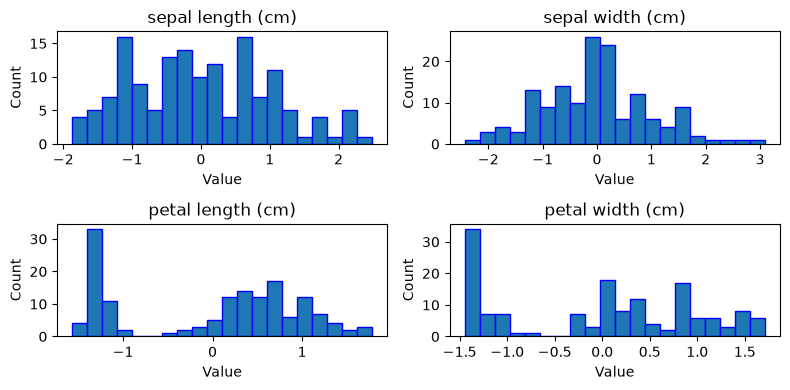

In [15]:
num_features = df.columns
rows = 2
cols = 2

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(8, 4))
axes = axes.flatten()

# Plot each feature
# enumerate -> (i, arr[i])
for i, feature in enumerate(df.columns[: rows * cols]):
    axes[i].hist(df[feature].dropna(), bins=20, edgecolor='blue')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
  
# auto space adjustment to prevent overlap  
plt.tight_layout()

In [16]:
# Correlation matrix
corr_mat = df.corr()
corr_mat

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

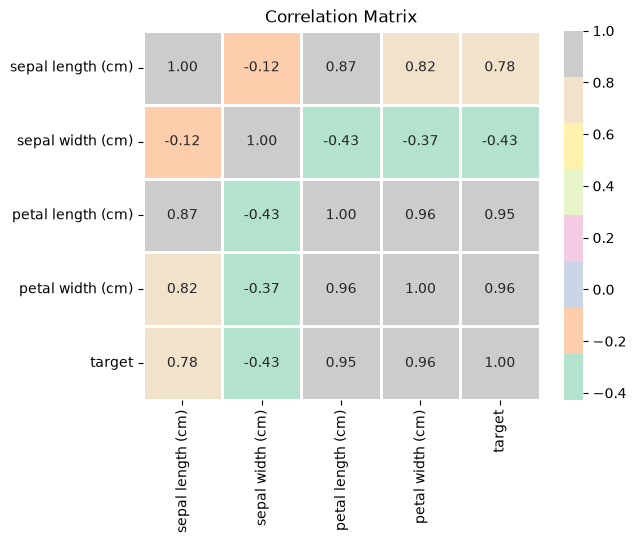

In [17]:
# Heatmap
sns.heatmap(corr_mat, annot=True, fmt='.2f' ,linewidth=1, cmap='Pastel2')
plt.title('Correlation Matrix')

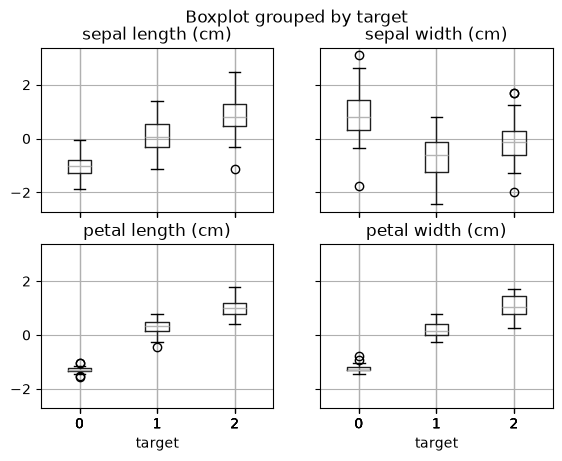

In [18]:
# Box Plot
df.boxplot(by ='target', column =['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'], grid = True);

In [19]:
# Value count
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

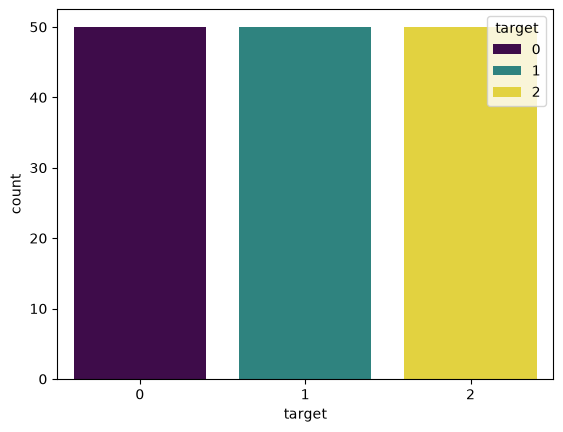

In [20]:
# Count Plot
sns.countplot(data=df, x="target", hue="target", palette='viridis')

## 2) Perform Train, Test & Validation split

Split the entire dataset into three parts in two steps.

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.30, random_state=42)

print(len(x_train), len(y_train))
print(len(x_test), len(y_test))
print(len(x_val), len(y_val))

78 78
38 38
34 34


## 3) Implemetation of KNN from scratch

In [22]:
from collections import Counter

# Some common distance metrics
def minkowski_distance(x, y, p=2):
    return np.sum(np.abs(x - y) ** p) ** (1 / p)

def cosine_similarity(x, y):
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

def chebyshev_distance(x, y):
    return np.max(np.abs(x - y))

# Raw implementation of KNN
class KNN:
    def __init__(self, k=3, distance_metric='euclidean', p=2):
        self.k = k
        self.distance_metric = distance_metric
        self.p = p  # parameter for Minkowski distance
        
    def fit_knn(self, x_train, y_train):       
        self.x_train = x_train
        self.y_train = y_train
        
    def _compute_distance(self, x):
        if self.distance_metric == 'minkowski':
            distances = [minkowski_distance(x, x_train, p=self.p) for x_train in self.x_train]
        elif self.distance_metric == 'cosine':
            distances = [cosine_similarity(x, x_train) for x_train in self.x_train]
        elif self.distance_metric == 'chebyshev':
            distances = [chebyshev_distance(x, x_train) for x_train in self.x_train]
        else:
            raise ValueError('Unsupported Distance Metric!')
        return distances
    
    def predict(self, x_test):
        predictions = []
        for x in x_test:
            distances = self._compute_distance(x)
            if self.distance_metric == 'cosine':
                # fetch indices with k highest values
                k_indices = np.argsort(distances)[-self.k:]
                # fetch its corresponding labels
                k_nearest_labels = [self.y_train[i] for i in k_indices]
                # assign the label which has highest count
                prediction = Counter(k_nearest_labels).most_common(1)[0][0]
            else:
                # fetch indices with k lowest values
                k_indices = np.argsort(distances)[:self.k]
                # fetch its corresponding labels
                k_nearest_labels = [self.y_train[i] for i in k_indices]
                # assign the label which has highest count
                prediction = Counter(k_nearest_labels).most_common(1)[0][0]
            predictions.append(prediction)
        return predictions
    

## 4) Execute & Evaluate on the Test dataset

In [27]:
from sklearn.metrics import accuracy_score

# Initialize KNN with k=3 using Minkowski distance with p=2
knn = KNN(k=3, distance_metric='minkowski', p=2)
knn.fit_knn(x_train, y_train)

# Predict on validation set and compute accuracy
y_val_prediction = knn.predict(x_val)
val_accuracy = accuracy_score(y_val, y_val_prediction)
print(f"Validation accuracy: {val_accuracy * 100:.2f}%")

# Predict on validation set and compute accuracy
y_test_prediction = knn.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_prediction)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Validation accuracy: 97.06%
Test accuracy: 100.00%


## 5) Verify results with Scikit Learn

In [28]:
# KNN using scikit-learn package's built-in definition - KNeighborsClassifier
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

from sklearn.neighbors import KNeighborsClassifier
knn_sk = KNeighborsClassifier(n_neighbors=3, algorithm='brute').fit(x_train, y_train)

val_prediction = knn_sk.predict(x_val)
test_prediction = knn_sk.predict(x_test)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Accuracy
accuracy = accuracy_score(y_test, test_prediction)
print(f'Accuracy: {accuracy:.2f}')

# Precision
precision = precision_score(y_test, test_prediction, average='weighted')
print(f'Precision: {precision:.2f}')

# Recall
recall = recall_score(y_test, test_prediction, average='weighted')
print(f'Recall: {recall:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, test_prediction)
print('Confusion Matrix:')
print(conf_matrix)

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
Confusion Matrix:
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


### Evaluation Metrics

1. The ROC curve shows how well a model distinguishes between two classes by plotting the true positive rate against the false positive rate for different thresholds.

2. The precision-recall curve focuses on the balance between precision (how accurate positive predictions are) and recall (how many actual positives are found) and is especially useful when one class is much less common than the other.


FPR:  {0: array([0., 0., 1.]), 1: array([0.        , 0.        , 0.        , 0.11111111, 1.        ]), 2: array([0.        , 0.        , 0.        , 0.03846154, 1.        ])}


TPR:  {0: array([0., 1., 1.]), 1: array([0.        , 0.90909091, 1.        , 1.        , 1.        ]), 2: array([0.  , 0.75, 1.  , 1.  , 1.  ])}


ROC_AUC:  {0: 1.0, 1: 1.0, 2: 1.0}




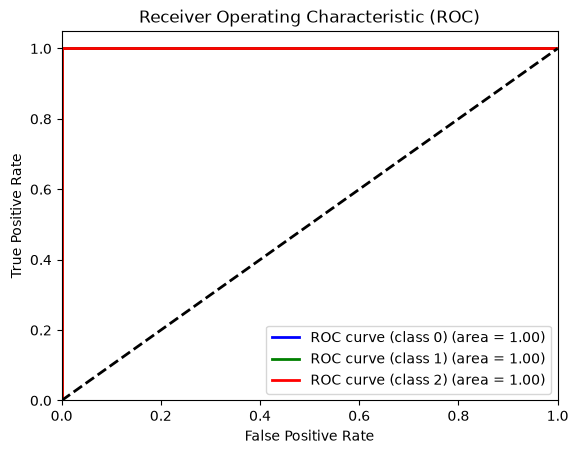

In [30]:
from sklearn.preprocessing import label_binarize

y_pred_prob = knn_sk.predict_proba(x_test)

# Binarize the output for ROC and Precision-Recall curves
y_test_binarized = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_binarized.shape[1]

# ROC curve and ROC AUC score
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = roc_auc_score(y_test_binarized[:, i], y_pred_prob[:, i])

print("FPR: ", fpr)
print("\n")

print("TPR: ", tpr)
print("\n")

print("ROC_AUC: ", roc_auc)
print("\n")

# Plot ROC curves for each class
plt.figure()
colors = ['blue', 'green', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC curve (class {i}) (area = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

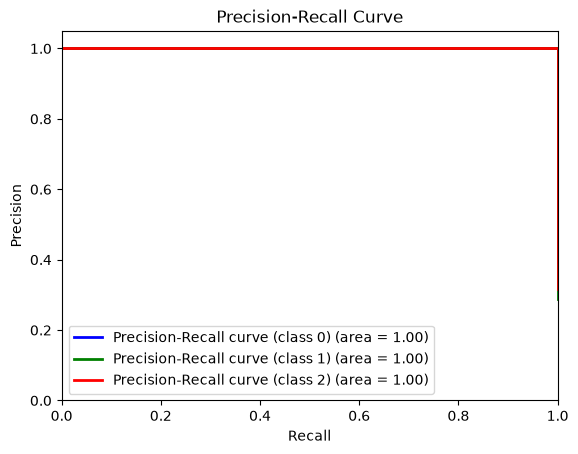

In [31]:
# Precision-Recall curve and average precision score
precision_vals = dict()
recall_vals = dict()
average_precision = dict()
for i in range(n_classes):
    precision_vals[i], recall_vals[i], _ = precision_recall_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    average_precision[i] = average_precision_score(y_test_binarized[:, i], y_pred_prob[:, i])

# Plot Precision-Recall curves for each class
plt.figure()
for i, color in zip(range(n_classes), colors):
    plt.plot(recall_vals[i], precision_vals[i], color=color, lw=2, label=f'Precision-Recall curve (class {i}) (area = {average_precision[i]:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

## 6) Visualize KNN decision boundaries with Scikit Learn

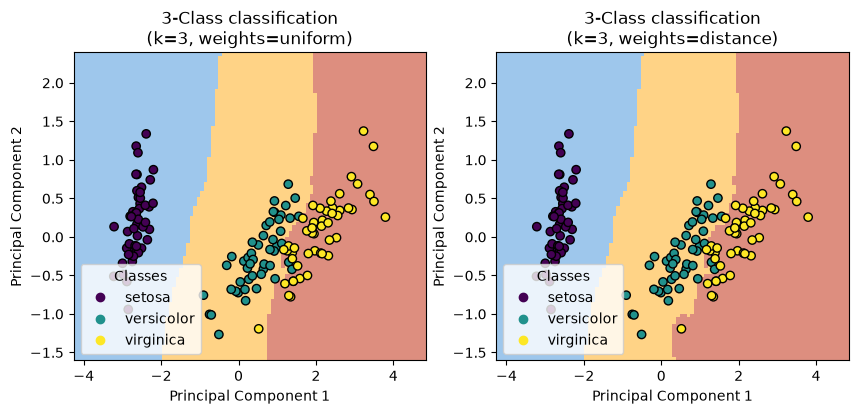

In [39]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.decomposition import PCA

# Load and prepare the data
iris = load_iris()
x, y = iris.data, iris.target

# Perform PCA to reduce the dimensions to 2 for visualization
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
x_train_pca, x_test_pca = train_test_split(x_pca, test_size=0.3, random_state=42)

# Plotting decision boundaries for different weight types
fig, axs = plt.subplots(ncols=2, figsize=(10, 4))

for ax, weights in zip(axs, ("uniform", "distance")):
    # Initialize and fit the KNN classifier
    knn = KNeighborsClassifier(weights=weights, n_neighbors=3)
    knn.fit(x_train_pca, y_train)

    # Plot the decision boundary
    disp = DecisionBoundaryDisplay.from_estimator(
        knn,
        x_test_pca,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel='Principal Component 1',
        ylabel='Principal Component 2',
        shading="auto",
        alpha=0.5,
        ax=ax,
    )

    # Scatter plot of the data points
    scatter = disp.ax_.scatter(x_pca[:, 0], x_pca[:, 1], c=y, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        iris.target_names,
        loc="lower left",
        title="Classes",
    )
    ax.set_title(f"3-Class classification\n(k={knn.n_neighbors}, weights={weights})")

plt.show()